In [1]:
import pandas as pd
import os

temi = [
    "structural_conflict", "force_as_resolution", "institutional_cynicism", 
    "power_dynamics", "extreme_individualism", "perceived_threat"
]

# 1. Carichiamo i metadati con il nome corretto della colonna degli incassi
df_finale = pd.read_csv("/work/data/metadata/metadata_final.csv", usecols=["imdb_id", "title", "domestic_box_office_gross"])
df_finale = df_finale.drop_duplicates(subset=["imdb_id"])

print(f"📊 Base metadati caricata: {len(df_finale)} film totali.")

# 2. Uniamo i file eliminando i duplicati
for tema in temi:
    percorso = f"llm_outputs/salienza_{tema}.csv"
    
    if os.path.exists(percorso):
        # on_bad_lines ci protegge da eventuali righe scritte male durante i crash
        df_tema = pd.read_csv(percorso, on_bad_lines='skip')
        
        # --- SISTEMA ANTI-DUPLICATI E SALVA RAM ---
        # Teniamo solo l'ultima analisi valida per ogni film, ignorando le righe multiple create per errore
        df_tema = df_tema.drop_duplicates(subset=["imdb_id"], keep="last")
        
        # Selezioniamo solo le colonne utili
        if "theme_salience" in df_tema.columns and "justification" in df_tema.columns:
            df_tema = df_tema[["imdb_id", "theme_salience", "justification"]]
            df_tema.columns = ["imdb_id", f"{tema}_score", f"{tema}_evidence"]
            
            # Uniamo al database principale
            df_finale = pd.merge(df_finale, df_tema, on="imdb_id", how="left")
            
            # Contiamo le righe VERE e uniche
            count = df_tema[f"{tema}_score"].notna().sum()
            print(f"✅ Unito tema '{tema}': {count} film unici analizzati.")
        else:
            print(f"⚠️ Colonne mancanti in {tema}.")
    else:
        print(f"⚠️ File non trovato per il tema: {tema}")

# 3. Salvataggio
percorso_finale = "llm_outputs/DATABASE_TESI_COMPLETO.csv"
df_finale.to_csv(percorso_finale, index=False)

print("-" * 30)
print(f"🎉 DATABASE CREATO E PULITO! Salvato in: {percorso_finale}")
print(f"📈 Dimensioni REALI: {df_finale.shape[0]} righe x {df_finale.shape[1]} colonne")

📊 Base metadati caricata: 3788 film totali.
✅ Unito tema 'structural_conflict': 3789 film unici analizzati.
✅ Unito tema 'force_as_resolution': 3788 film unici analizzati.
✅ Unito tema 'institutional_cynicism': 3787 film unici analizzati.
✅ Unito tema 'power_dynamics': 3788 film unici analizzati.
✅ Unito tema 'extreme_individualism': 3788 film unici analizzati.
✅ Unito tema 'perceived_threat': 3788 film unici analizzati.
------------------------------
🎉 DATABASE CREATO E PULITO! Salvato in: llm_outputs/DATABASE_TESI_COMPLETO.csv
📈 Dimensioni REALI: 3788 righe x 15 colonne


In [2]:
import os
for f in os.listdir("llm_outputs"):
    if f.startswith("salienza_"):
        line_count = sum(1 for line in open(f"llm_outputs/{f}")) - 1
        print(f"📊 {f.replace('salienza_', '').replace('.csv', ''):<25}: {line_count} film analizzati")

📊 institutional_cynicism   : 3788 film analizzati
📊 extreme_individualism    : 3788 film analizzati
📊 force_as_resolution      : 3802 film analizzati
📊 perceived_threat         : 3807 film analizzati
📊 power_dynamics           : 3797 film analizzati
📊 structural_conflict      : 4090 film analizzati


🎨 Grafico salvato come 'distribuzione_voti_temi.png' nella cartella principale.


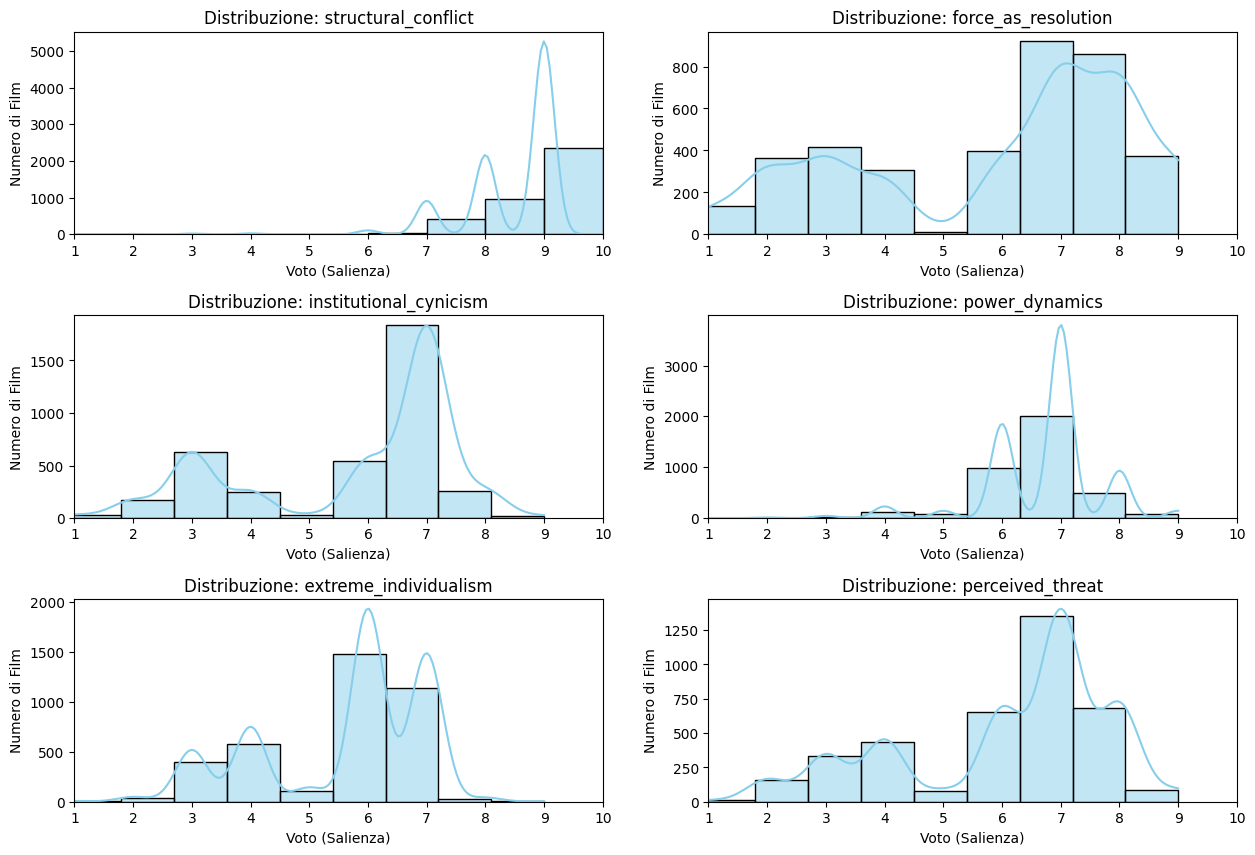

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carichiamo il database unificato
df = pd.read_csv("llm_outputs/DATABASE_TESI_COMPLETO.csv")

# 2. Identifichiamo le colonne dei voti (quelle che finiscono con _score)
score_cols = [col for col in df.columns if col.endswith("_score")]

# 3. Creiamo i grafici
plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(score_cols, 1):
    plt.subplot(3, 2, i)
    
    # Filtriamo i dati validi (togliamo i NaN di chi non è ancora stato analizzato)
    data = df[col].dropna()
    
    if not data.empty:
        sns.histplot(data, bins=10, kde=True, color="skyblue")
        plt.title(f"Distribuzione: {col.replace('_score', '')}")
        plt.xlabel("Voto (Salienza)")
        plt.ylabel("Numero di Film")
        plt.xlim(1, 10)
    else:
        plt.text(0.5, 0.5, 'In attesa di dati...', ha='center')

# 4. Salvataggio dell'immagine per la tesi
plt.savefig("distribuzione_voti_temi.png", bbox_inches='tight')
print("🎨 Grafico salvato come 'distribuzione_voti_temi.png' nella cartella principale.")

🔥 Heatmap salvata! Cerca 'matrice_correlazione_temi.png' nei file.


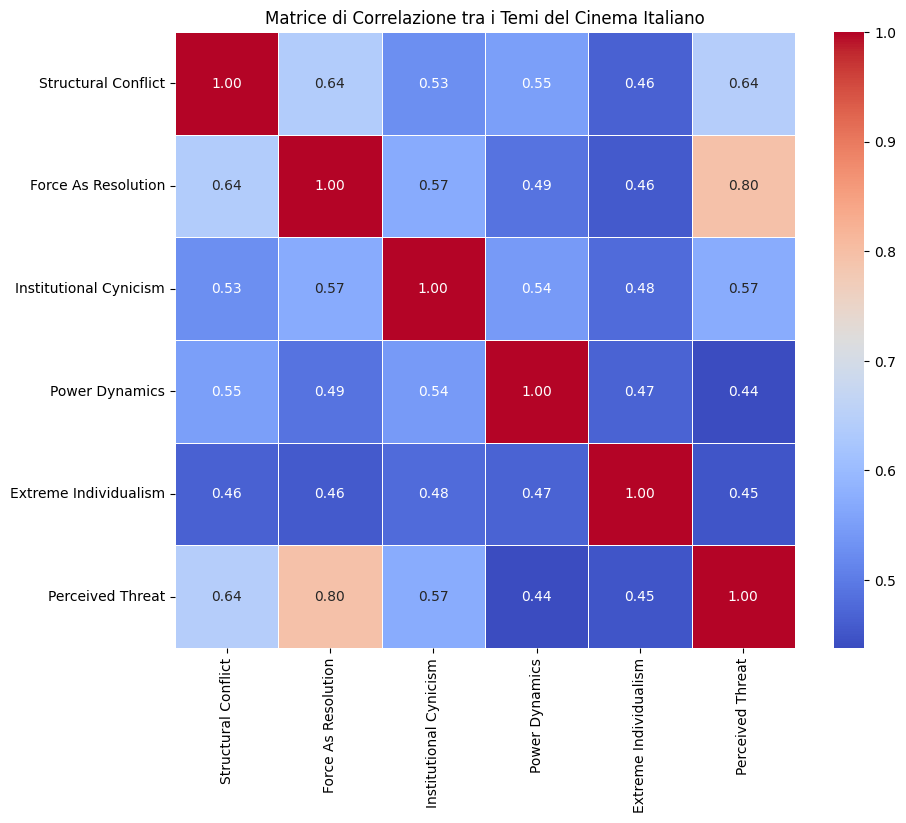

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carichiamo il database (leggero per la RAM)
df = pd.read_csv("llm_outputs/DATABASE_TESI_COMPLETO.csv")

# 2. Selezioniamo solo le colonne dei voti
score_cols = [col for col in df.columns if col.endswith("_score")]
df_scores = df[score_cols].copy()

# Rinominiamo le colonne per una lettura più pulita nel grafico
df_scores.columns = [c.replace("_score", "").replace("_", " ").title() for c in df_scores.columns]

# 3. Calcolo della correlazione
corr = df_scores.corr()

# 4. Creazione del grafico
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice di Correlazione tra i Temi del Cinema Italiano")

# 5. Salvataggio
plt.savefig("matrice_correlazione_temi.png", bbox_inches='tight')
print("🔥 Heatmap salvata! Cerca 'matrice_correlazione_temi.png' nei file.")

In [5]:
import pandas as pd

df = pd.read_csv("llm_outputs/DATABASE_TESI_COMPLETO.csv")
score_cols = [col for col in df.columns if col.endswith("_score")]

print("🏆 I FILM PIÙ RAPPRESENTATIVI PER TEMA:")
print("-" * 50)

for col in score_cols:
    tema = col.replace("_score", "").upper()
    # Prendiamo i primi 10 film ordinati per voto decrescente
    top_10 = df.sort_values(by=col, ascending=False).head(10)
    
    print(f"\n📍 TEMA: {tema}")
    for i, (idx, row) in enumerate(top_10.iterrows(), 1):
        # Mostriamo Titolo, Voto e un pezzetto della giustificazione
        voto = row[col]
        evidenza = str(row[col.replace("_score", "_evidence")])[:100] + "..."
        print(f"{i}. {row['title']} (Voto: {voto})")
        print(f"   📝 Perché: {evidenza}")

🏆 I FILM PIÙ RAPPRESENTATIVI PER TEMA:
--------------------------------------------------

📍 TEMA: STRUCTURAL_CONFLICT
1. Avengers: Infinity War (Voto: 10.0)
   📝 Perché: The film's narrative is almost entirely driven by the escalating conflict with Thanos. From the open...
2. United 93 (Voto: 10.0)
   📝 Perché: The subtitles depict a hijacking scenario, making structural conflict the dominant engine of the fil...
3. Wag the Dog (Voto: 10.0)
   📝 Perché: Structural conflict is the dominant engine of the film's narrative. The entire plot revolves around ...
4. Saw III (Voto: 10.0)
   📝 Perché: The film's narrative is almost entirely driven by conflict. The subtitles reveal a series of 'games'...
5. The Terminal (Voto: 9.0)
   📝 Perché: Structural conflict is the dominant engine of the film's narrative. Viktor Navorski is trapped in an...
6. Ladder 49 (Voto: 9.0)
   📝 Perché: Structural conflict is the dominant engine of the film's narrative. The subtitles depict firefighter...
7. Ray (V

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e08cfdf8-9b6e-44e8-b36c-3dd235d85ba1' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>